# PHYS 309 Assignment 1

### Getting started

<ul>
    <li>If you do not already have the <a href="https://www.anaconda.com/products/distribution">Anaconda <tt>python</tt> distribution</a>, click the link to install the individual, free version</li>
    <li>Download this notebook to your own computer, open with <tt>Jupyter</tt> notebook or lab, and complete the missing code. See the <a href="https://docs.jupyter.org/en/latest/start/index.html"><tt>Jupyter</tt> documentation</a> for help.</li>
</ul>

<strong>Instead of putting in the values of physical constants such as $c$ and $\epsilon_0$ by hand, use SI values pre-programmed into [scipy.constants](https://docs.scipy.org/doc/scipy/reference/constants.html).

### Set up <tt>python</tt> environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt

 # Contains physical constants defined in SI units (default) as well as other systems
from scipy import constants

# Make easily readable plots with large axis labels
plt.rcParams.update({"font.size":16, "axes.labelsize":16, "font.family":"sans-serif", 
                     "font.sans-serif":"Arial"})

### Questions


Recall that the speed of light in vacuum is 
\begin{equation}
c = \frac{1}{\sqrt{\epsilon_0 \mu_0}}, \; \; \; \; \; (1)
\end{equation}
where $\epsilon_0 = 8.85 \times 10^{-12}$ F/m (Farads per meter)$^{*}$ is the electric permittivity of free space and $\mu_0 = 1.26 \times 10^{-6}$ N/A$^2$ (Newtons per Ampere$^2$)$^{**}$ is the magnetic permeability of free space. The electric field created by a point charge $q$ is
\begin{equation}
E = \frac{1}{4 \pi \epsilon_0} \frac{q}{r^2}. \; \; \; \; (2)
\end{equation}
Suppose a charged particle is moving at some fraction of the speed of light in vacuum ($v_q = f c; \; 0 < f < 1$) as seen in reference frame $S$. Reference frame $S^{\prime}$ is co-moving with the point charge, so that $\frac{dx^{\prime}}{dt^{\prime}} = v^{\prime}_q = 0$ in frame $S^{\prime}$. To make the math easier, put $q$ at the origin of $S^{\prime}$.

To understand Einstein's motivation for developing the special theory of relativity, make the <strong>incorrect, erroneous, and wrong</strong> assumption that the Galilean velocity transformation holds true for all values of $f$:
\begin{equation}
\frac{dx^{\prime}}{dt^{\prime}} = \frac{dx}{dt} - v_q \; \; \; (3)
\end{equation}

<ol>
    <li>Assume the charged particle is an electron. Using Equation 2, calculate and plot the electric field as a function of distance $r^{\prime}$ from $q$ in frame $S^{\prime}$. Choose an x-axis range that makes sense to you and label both axes with correct units.</li>
</ol>

$^{*}$Farad = Coulomb/Volt: Farad is the unit of capacitance, which measures the amount of charge necessary to increase the electric potential of a system by 1 Volt. Farads/meter measure how much capacitance you get per meter of free space between yourself and a charged particle.

$^{**}$Newtons/Ampere$^2$ = Newtons/(Coulombs/second)$^2$. $\mu_0$ measures how effective inductance is at creating magnetic force in free space.

'Either linear or logarithmic axes are fine; I put in both just to showcase the different \noptions. Note, we have to plot -E instead of E for the logarithmic scaling.'

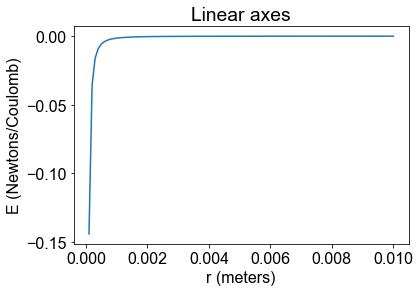

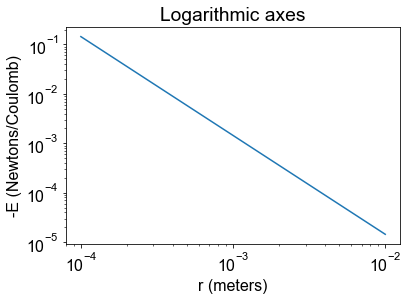

In [2]:
# Define constant k = 1/(4 pi eps0)
# Note: numpy has the value of pi coded in
k = 1 / (4 * np.pi * constants.epsilon_0)

# Define a one-line "lambda function" to find the E field in terms of k, q, and r
E_field = lambda q, r: k * q / r**2

# Note: your function could also look like
# def E_field(q, r):
#     return k*q/r**2

# Define a vector of radii using np.linspace(), which makes an evenly spaced range of numbers
# since distance units are meters, this range goes from 100 micron to 1 cm in steps of 10 micron
# Note: np.arange() would also work
radii = np.linspace(0.0001, 0.01, num=100, endpoint=True) # endpoint=True means 0.01 is included

# Make plot 1 with linear y-axis
plt.plot(radii, E_field(-constants.e, radii)) # constants.e is elementary charge
plt.xlabel('r (meters)')
plt.ylabel('E (Newtons/Coulomb)')
plt.title('Linear axes')

# Make plot 2 with logarithmic axes
plt.figure() # New figure window
plt.loglog(radii, E_field(constants.e, radii))
plt.xlabel('r (meters)')
plt.ylabel('-E (Newtons/Coulomb)')
plt.title('Logarithmic axes')

'''Either linear or logarithmic axes are fine; I put in both just to showcase the different 
options. Note, we have to plot -E instead of E for the logarithmic scaling.'''

<ol start=2>
    <li>The Galilean velocity transformation suggests that objects can "catch up" with light, so that light in a vacuum appears to be going slower than the value of $c$ from Equation (1). Make a plot of $c^{\prime}$, the <strong>incorrect</strong> speed of light in frame $S^{\prime}$ according to the Galilean transformation, as a function of $f$. Put units on the axes where appropriate.</li>
</ol>

Text(0.5, 1.0, '$c^{\\prime} = c(1-f)$')

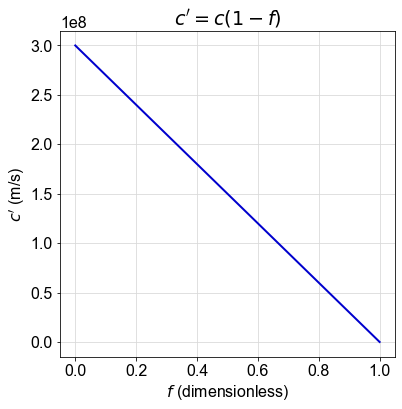

In [3]:
# Another quick lambda function to define c'
cprime = lambda f: constants.c * (1-f)

# A range of f values from 0 to 1, including both end points
f = np.linspace(0, 1, num=101, endpoint=True)

# A simple plot like the one above is all that's needed for full credit. However,
# here's a fancier one so you can see what matplotlib can do
plt.figure(figsize=(6,6))
plt.plot(f, cprime(f), color='mediumblue', linewidth=2)
plt.grid(color='0.85')
plt.xlabel(r"$f$ (dimensionless)")
plt.ylabel(r"$c^{\prime}$ (m/s)")
plt.title(r"$c^{\prime} = c(1-f)$")

<ol start=3>
    <li>In frame $S^{\prime}$, something has to give: either Equation (1) is no longer true, or the values of $\epsilon_0$ and/or $\mu_0$ have to change. Suppose Equation (1) is still true and $\mu_0 = \mu_0^{\prime}$. Make a plot with two vertically stacked subplots. The top subplot should show $\epsilon_0^{\prime}$ as a function of $f$, while the bottom plot should show the electric field $E^{\prime} = \frac{1}{4 \pi \epsilon_0^{\prime}} \frac{q}{{r^{\prime}}^2}$ at $r^{\prime} = 1 \mu \mathrm{m} = 10^{-6}$ m as a function of $f$. Put units on the axes where appropriate.</li>
</ol>

<ipython-input-4-4b6d6ddf5abe>:3: RuntimeWarning: divide by zero encountered in true_divide
  return 1 / (constants.mu_0 * cp**2)


'You could use logarithmic scaling for the top plot'

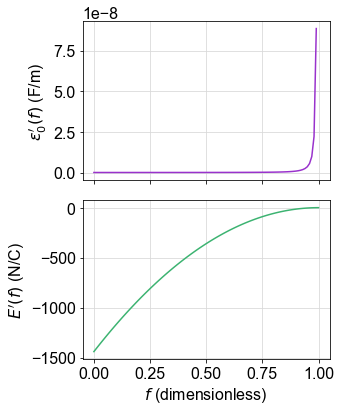

In [4]:
# Function to calculate epsilon_0'
def epsilon_0_prime(cp):
    return 1 / (constants.mu_0 * cp**2)

# We could also do
# epsilon_0_prime = lambda cp: 1 / (constants.mu_0 * cp**2)

# Use our epsilon_0_prime function to construct an array of epsilon_0' values for the
# vector of f we defined in question 2
eps_0_prime = epsilon_0_prime(cprime(f)) # Function calls can be nested

# We can't use our E_field() function from question 1 because it's defined for standard epsilon_0
# Instead let's calculate an array of E_field_prime values with r' = 10^-6 m (1 micron) and
# q = electron charge
micron = 1e-6
E_field_prime = -constants.e / (4 * np.pi * eps_0_prime * micron**2)

# Make the figure and pair of axes
# sharex=True means both will have the same x coordinates
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(5,6))

# Plot eps_0'
ax1.plot(f, eps_0_prime, color='darkorchid')
ax1.set_ylabel(r"$\epsilon_0^{\prime}(f)$ (F/m)")
ax1.grid(color='0.85')

# Plot E'
ax2.plot(f, E_field_prime, color='mediumseagreen')
ax2.set_ylabel(r"$E^{\prime}(f)$ (N/C)")
ax2.set_xlabel(r"$f$ (dimensionless)")
ax2.grid(color='0.85')

# Shrink the vertical space between the plots
fig.tight_layout()

'''You could use logarithmic scaling for the top plot'''

<ol start=4>
    <li>Now assume $f = 0.5$. In the same plot window, plot $E^{\prime}(r^{\prime})$ given by Equation 2 (same curve as in Problem 1) <em>and</em> $E^{\prime}(r^{\prime})$ calculated as in Problem 3, where $\epsilon_0^{\prime}$ is a function of $f$. Do you notice a problem?</li>
</ol>

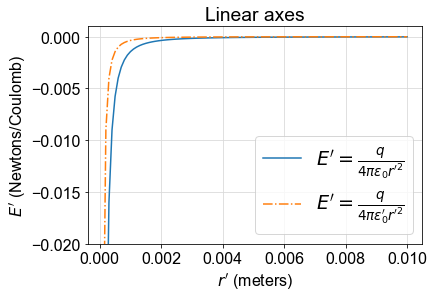

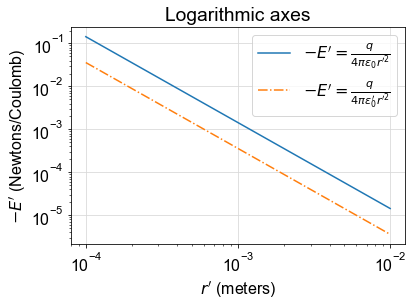

In [5]:
# Re-use function from question 3 to calculate e0' for f = 0.5
eps_0_f05 = epsilon_0_prime(cprime(0.5))

# Calculate an array of E' values for e0' = eps_0_f05 from above
E_f05 = -constants.e / (4 * np.pi * eps_0_f05 * radii**2)

# Re-use E_field function from question 1 to calculate 
plt.plot(radii, E_field(-constants.e, radii), 
         label=r"$E^{\prime} = \frac{q}{4 \pi \epsilon_0 r^{\prime 2}}$")
plt.plot(radii, E_f05, linestyle='-.',
         label=r"$E^{\prime} = \frac{q}{4 \pi \epsilon_0^{\prime} r^{\prime 2}}$")
plt.xlabel(r"$r^{\prime}$ (meters)")
plt.ylabel(r"$E^{\prime}$ (Newtons/Coulomb)")
plt.title('Linear axes')
plt.ylim([-0.02, 0.001])
plt.legend(loc='best', fontsize='large')
plt.grid(color='0.85')

# Same plot, but with logarithmic axes
# Re-use E_field function from question 1 to calculate
plt.figure()
plt.loglog(radii, E_field(constants.e, radii), 
         label=r"$-E^{\prime} = \frac{q}{4 \pi \epsilon_0 r^{\prime 2}}$")
plt.loglog(radii, -E_f05, linestyle='-.',
         label=r"$-E^{\prime} = \frac{q}{4 \pi \epsilon_0^{\prime} r^{\prime 2}}$")
plt.xlabel(r"$r^{\prime}$ (meters)")
plt.ylabel(r"$-E^{\prime}$ (Newtons/Coulomb)")
plt.title('Logarithmic axes')
plt.legend(loc='best')
plt.grid(color='0.85')

# The two curves don't match, which means E&M breaks down if you use Galilean transformation

<ol start=5>
    <li>To resolve the issues revealed by the plot from Problem 4, you may suggest setting $\epsilon_0^{\prime} = \epsilon_0$ and allowing $\mu_0^{\prime}$ to vary with $f$. Let's explore that solution. To accompany the point charge in problems 1-4, add a current loop that's also at rest in frame $S^{\prime}$. Recall that the magnitude of the magnetic field strength at the center of the loop in frame $S$ is $B = \frac{\mu_0 I}{2R}$, where $I$ is the current and $R$ is the radius of the loop. Suppose $I = 1$ A and $R = 1$ m. Assume $E^{\prime} = E$, $B^{\prime} = B$, and $c^{\prime}$ depends on $f$ as in problem 2. Plot $\mu_0$ as a function of $f$.</li>
</ol>

<ipython-input-6-4d57cb5f5496>:3: RuntimeWarning: divide by zero encountered in true_divide
  mu_0_prime = 1 / (constants.epsilon_0 * cprime(f)**2)


Text(0.5, 1.0, 'Semilog-y plot: axis is uniform in $\\log_{10}(\\mu_0^{\\prime})$')

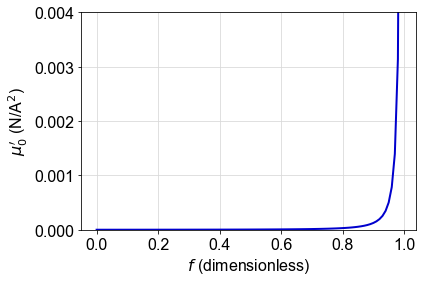

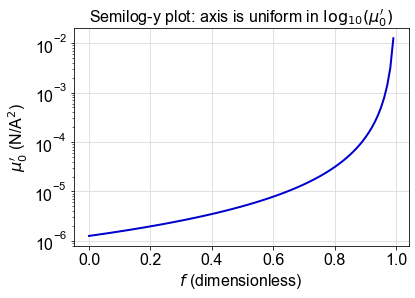

In [6]:
# Do the pencil and paper calculations before you start putting things in the computer:
# I solved for mu_0' = 1 / (eps_0 c'^2). eps_0' = eps0 because E' = E.
mu_0_prime = 1 / (constants.epsilon_0 * cprime(f)**2)
plt.figure(figsize=(6,4))
plt.plot(f, mu_0_prime, color='mediumblue', linewidth=2)
plt.grid(color='0.85')
plt.xlabel(r"$f$ (dimensionless)")
plt.ylabel(r"$\mu_0^{\prime}$ (N/A$^2$)")
plt.ylim([0,0.004])

# Make a semilog-y plot
plt.figure(figsize=(6,4))
plt.semilogy(f, mu_0_prime, color='mediumblue', linewidth=2)
plt.grid(color='0.85')
plt.xlabel(r"$f$ (dimensionless)")
plt.ylabel(r"$\mu_0^{\prime}$ (N/A$^2$)")
plt.title(r"Semilog-y plot: axis is uniform in $\log_{10}(\mu_0^{\prime})$", fontsize='medium')

'''Here I show another plotting option: semilog-y'''

<ol start=6>
<li>If we calculate $c^{\prime}$ using the Galilean transformation in Equation 3, is there any value of $f$ for which $E^{\prime} = E$ <strong>and</strong> $B^{\prime} = B$? Make a graph to illustrate your answer.</li>
</ol>

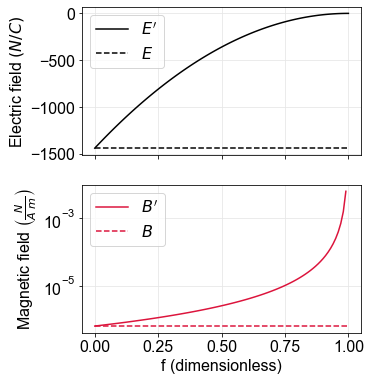

In [7]:
E_field_correct = -constants.e / (4 * np.pi * constants.epsilon_0 * micron**2)
B_field_correct = constants.mu_0 / 2 # equal to mu_0 I / (2 R) with R = 1 m, I = 1 A
B_field_prime = mu_0_prime / 2 # Same as above, except that mu_0' depends on f

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(5,6))

ax1.plot(f, E_field_prime, label=r"$E^{\prime}$", color='k')
ax1.plot(f, E_field_correct*np.ones(len(f)), label=r"$E$", color='k', ls='--')
ax1.set_ylabel(r"Electric field $(N/C)$")
ax1.legend(loc='upper left')
ax1.grid(color='0.9')

ax2.semilogy(f, B_field_prime, label=r"$B^{\prime}$", color='crimson')
ax2.semilogy(f, B_field_correct*np.ones(len(f)), label=r"$B$", color='crimson', ls='--')
ax2.set_ylabel(r"Magnetic field $\left( \frac{N}{A \; m} \right)$")
ax2.set_xlabel('f (dimensionless)')
ax2.legend(loc='upper left')
ax2.grid(color='0.9')

$E^{\prime} = E$ and $B^{\prime} = B$ only at $f = 0$.